<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/nebula_NGC_602.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Nebula NGC 602**

https://de.m.wikipedia.org/wiki/NGC_602

Near the outskirts of the Small Magellanic Cloud, a satellite galaxy roughly 200 000 light-years from Earth, lies the young star cluster NGC 602.
Brown dwarfs are the more massive cousins of giant gas planets (typically ranging from roughly 13 to 75 Jupiter masses, and sometimes lower).
They are free-floating, meaning that they are not gravitationally bound to a star as exoplanets are.
However, some of them share characteristics with exoplanets, like their atmospheric composition and storm patterns.
This discovery highlights the power of using both Hubble and Webb to study young stellar clusters.
Hubble showed that NGC602 harbors very young low mass stars, but only with Webo we can finally see the extent and the significance of the substellar mass formation in this cluster.

In [1]:
!pip install astropy astroquery -q
from astroquery.ipac.irsa import Irsa
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astropy import coordinates
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import matplotlib.pyplot as plt
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 912.9/912.9 kB 21.4 MB/s eta 0:00:00


In [2]:
# Get skycoordinates of desired object
galaxy = Simbad.query_object('ngc602')
ra_hms = galaxy['RA'][0]
dec_dms = galaxy['DEC'][0]
print(galaxy)

 MAIN_ID       RA          DEC      RA_PREC ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
            "h:m:s"      "d:m:s"            ...                                                    
--------- ------------ ------------ ------- ... -------------- ------------------- ----------------
NGC   602 01 29 32.133 -73 33 38.13       7 ...              O 2012ApJ...748...64G                1


In [3]:
print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

RA (h:m:s): 01 29 32.133
DEC (d:m:s): -73 33 38.13


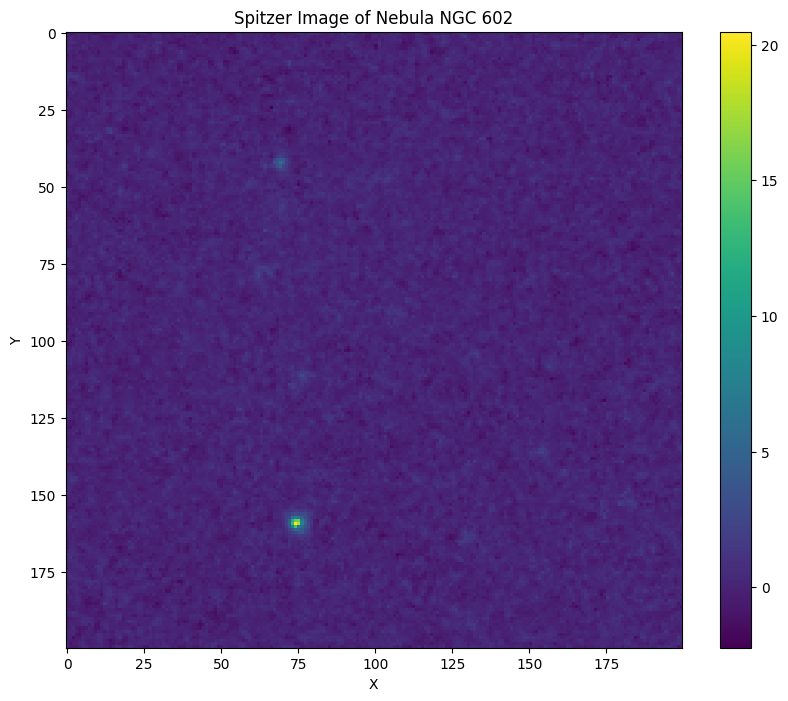

In [4]:
# Simple image access queries from IRSA for M31 galaxy images from Spitzer telescope
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
spitzer_images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection='spitzer_seip').to_table()

# Open a cutout image for one of the science images
science_image = spitzer_images[spitzer_images['dataproduct_subtype'] == 'science'][0]
with fits.open(science_image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8))
plt.imshow(cutout.data, cmap='viridis')
plt.colorbar()
plt.title('Spitzer Image of Nebula NGC 602')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()